In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import h5py
import scipy
from scipy.optimize import curve_fit

In [97]:
def readInOutputFile(outputFilename):
	optionsStructType = np.dtype([
		('B0', np.float64, 3),
		('E', np.float64, 3),
		('L', np.float64, 3),
		('yi', np.float64, 3),
		('posHistBins', np.float64, 3),
		('m', np.float64),
		('t0', np.float64),
		('tf', np.float64),
		('rtol', np.float64),
		('atol', np.float64),
		('beta', np.float64),
		('uround', np.float64),
		('safe', np.float64),
		('fac1', np.float64),
		('fac2', np.float64),
		('hmax', np.float64),
		('h', np.float64),
		('T', np.float64),
		('gamma', np.float64),
		('V', np.float64),
		('swapStepSize', np.float64),
		('ioutInt', np.float64),
		('nmax', np.uint32),
		('integratorType', np.int32),
		('numParticles', np.int32),
		('numPerGPUBlock', np.int32),
		('iout', np.int32),
		('numPhiBins', np.int32),
		('numThetaBins', np.int32),
		('dist', 'S', 1),
		('output', 'S', 1),
		('gas_coll', bool),
		('diffuse', bool),
		('gravity', bool),
		('pad', 'S', 7) #this is padding space just designed to fix the structure padding done in C++
	])
	file = open(outputFilename, 'rb')
	parameters = np.fromfile(file, count=1, dtype=optionsStructType)[0]
	data = None
	if parameters['output'] == b'n':
		#in this case it was the full dump of all particle data
		outputDtype = np.dtype([
			('t', '<f8'),
			('xx', '<f8'),
			('xy', '<f8'),
			('xz', '<f8'),
			('sx', '<f8'),
			('sy', '<f8'),
			('sz', '<f8')])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
		numPer = int((parameters['tf']-parameters['t0'])/parameters['ioutInt'])+1
		data = data.reshape(numPer, parameters['numParticles']).T #this returns the data in a little more convenient format, I think
	elif parameters['output'] == b'h':
		#this is the histogram output format instead now
		numx = int(parameters['L'][0]/parameters['gridSize'])+1
		numy = int(parameters['L'][1]/parameters['gridSize'])+1
		numz = int(parameters['L'][2]/parameters['gridSize'])+1
		
		numVecBins = int(np.ceil(2.0/parameters['vecBinSize']))
		
		xbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
		ybins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize']) 
		zbins = np.arange(-parameters['L'][0]/2.0, parameters['L'][0]/2.0, parameters['gridSize'])
		sbins = np.arange(-1.0, 1.0, parameters['vecBinSize'])
		outputDtype = np.dtype([
			('t', np.float64),
			('x', np.uint32, numx),
			('y', np.uint32, numy),
			('z', np.uint32, numz),
			('sx', np.uint32, numVecBins),
			('sy', np.uint32, numVecBins),
			('sz', np.uint32, numVecBins)
		])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
		data = {'xbins': xbins,
			   'ybins': ybins,
			   'zbins': zbins,
			   'sbins': sbins,
			   'data': data}
	elif parameters['output'] == b'a':
		outputDtype = np.dtype([
			('t', np.float64),
			('sx', np.float64),
			('dsx', np.float64),
			('sy', np.float64),
			('dsy', np.float64),
			('sz', np.float64),
			('dsz', np.float64)
		])
		file.seek(0, 0)
		data = np.fromfile(file, dtype=outputDtype, offset=parameters.nbytes)
	file.close()
	return parameters, data

def shiftDatapoints(phis):
    mean = np.mean(phis) #calculate the mean value
    shifted = np.copy(phis)
    #any values less than the mean by np.pi should be shifted up
    shifted[shifted<=(mean-np.pi)] += 2.0*np.pi
    shifted[shifted>=(mean+np.pi)] -= 2.0*np.pi
    std = np.std(shifted)
    shifted[shifted<(mean-np.pi/2)] = np.nan
    shifted[shifted>(mean+np.pi/2)] = np.nan
    return shifted

def analyzeDataset(dset, randomSample = False):
    times = np.sort(np.unique(dset[0]['t']))
    phis = np.arctan2(dataset['sy'], dataset['sz'])
    for i in range(len(times)):
        if randomSample:
            phis[:,i] = shiftDatapoints(np.random.choice(phis[:,i], size=phis[:,i].shape))
        else:
            phis[:,i] = shiftDatapoints(phis[:,i])
    means = np.nanmean(phis, axis=0)
    stds = np.nanstd(phis, axis=0)
    return times, means, stds

def bootstrapResults(dset, numBootstrap):
    times = []
    means = []
    stds = []
    for i in range(numBootstrap):
        print(i)
        time, mean, std = analyzeDataset(dset, randomSample=True)
        times.append(time)
        means.append(mean)
        stds.append(std)
    times = times[0]
    means = np.array(means)
    stds = np.array(stds)
    return times, means, stds

## No E Field Dataset

In [3]:
directory = '/storage/home/hcoda1/9/dmathews33/scratch/noEField/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

18296


In [4]:
parameters = []
dataset = []
for f in original:
    temp = readInOutputFile(f)
    parameters.append(temp[0])
    dataset.append(temp[1])
parameters = np.array(parameters)
dataset = np.concatenate(np.array(dataset), axis=0)

In [20]:
np.random.choice?

In [34]:
def analyzeDataset(dset, randomSample = False):
    times = np.sort(np.unique(dset[0]['t']))
    phis = np.arctan2(dataset['sy'], dataset['sz'])
    for i in range(len(times)):
        if randomSample:
            phis[:,i] = shiftDatapoints(np.random.choice(phis[:,i], size=phis[:,i].shape))
        else:
            phis[:,i] = shiftDatapoints(phis[:,i])
    means = np.nanmean(phis, axis=0)
    stds = np.nanstd(phis, axis=0)
    return times, means, stds

def bootstrapResults(dset, numBootstrap):
    times = []
    means = []
    stds = []
    for i in range(numBootstrap):
        print(i)
        time, mean, std = analyzeDataset(dset, randomSample=True)
        times.append(time)
        means.append(mean)
        stds.append(std)
    times = times[0]
    means = np.array(means)
    stds = np.array(stds)
    return times, means, stds

In [35]:
times, means, stds = analyzeDataset(dataset)

In [38]:
bootstrapRes = bootstrapResults(dataset, 10)

0
1
2
3
4
5
6
7
8
9


8355840
[3.e-06 0.e+00 0.e+00] 0.4 [0. 0. 0.] [0.07 0.1  0.4 ]
-623.4 0.010078898471574569


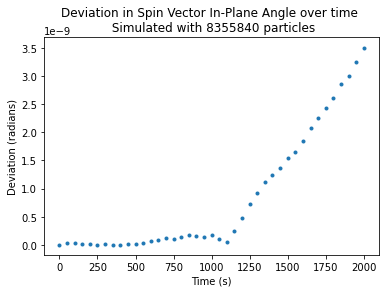

1.7459711454392845e-12


In [95]:
numParticles = phis.shape[0]
print(numParticles)
print(parameters[0]['B0'], parameters[0]['T'], parameters[0]['E'], parameters[0]['L'])
w = parameters[0]['gamma']*np.sqrt(np.sum(np.square(parameters[0]['B0']))) #calculate the frequency
period = abs(2.0*np.pi/w) #calculate the period of the oscillation
print(w, period)
locationInPeriod = (times/period)%1
trueAngle = locationInPeriod*2.0*np.pi
shiftedMeans = np.copy(np.mean(bootstrapRes[1], axis=0))
shiftedMeans[shiftedMeans<0] += np.pi*2.0
shiftedMeans[shiftedMeans>0] = 2.0*np.pi - shiftedMeans[shiftedMeans>0]
#plt.scatter(times, shiftedMeans)
#plt.scatter(times, trueAngle)
plt.errorbar(times, abs(shiftedMeans-trueAngle), yerr=stds/np.sqrt(numParticles), marker='.', linestyle='none')
#plt.plot(times, trueAngle)
plt.xlabel('Time (s)')
plt.ylabel('Deviation (radians)')
plt.title('Deviation in Spin Vector In-Plane Angle over time \n Simulated with '+str(numParticles) +' particles')
plt.show()
print(max(abs(shiftedMeans-trueAngle))/2000)

In [65]:
bootstrapRes[1].shape

(10, 41)

In [96]:
deviations = np.copy(bootstrapRes[1])
deviations[deviations<0] += np.pi*2.0
deviations[deviations>0] = 2.0*np.pi - deviations[deviations>0]
deviations = np.subtract(deviations, trueAngle[None,])[:]

slopes = deviations[:]/bootstrapRes[0][:]
meanSlopes = np.nanmean(slopes, axis=0)
stdSlopes = np.nanstd(slopes, axis=0)
print(meanSlopes[:]/(2.0*np.pi))
print(stdSlopes[:]/(2.0*np.pi))

[            nan -1.09739880e-13 -3.96340934e-14  1.63277898e-14
 -6.84306942e-15 -3.87154079e-15 -7.76989483e-15 -1.55280359e-15
  3.08054391e-16  8.21717113e-15  2.95532900e-15  7.85176788e-15
  1.67308838e-14  2.00497274e-14  2.86681202e-14  2.27816488e-14
  2.85103331e-14  3.20674665e-14  2.89716098e-14  2.33144702e-14
  2.68627316e-14  1.59082712e-14 -7.51086382e-15 -3.49825860e-14
 -6.32378261e-14 -9.23264814e-14 -1.13709408e-13 -1.30845637e-13
 -1.40647941e-13 -1.48929490e-13 -1.63705383e-13 -1.68613949e-13
 -1.83898342e-13 -2.00665521e-13 -2.11400822e-13 -2.21801667e-13
 -2.30975360e-13 -2.46222146e-13 -2.51461781e-13 -2.64731890e-13
 -2.77879938e-13]
[           nan 2.14778749e-16 4.60234532e-16 3.80414216e-16
 5.91837814e-16 2.73488717e-16 6.43591284e-16 7.78349973e-16
 4.75576881e-16 7.55030495e-16 7.86010921e-16 5.62214559e-16
 8.90807711e-16 6.72254458e-16 9.06427530e-16 8.94759602e-16
 9.00014781e-16 1.08950912e-15 9.35217098e-16 8.77754524e-16
 9.08284793e-16 9.48429924e

<ipython-input-96-434cad85a4bb>:6: RuntimeWarning: invalid value encountered in true_divide
  slopes = deviations[:]/bootstrapRes[0][:]
<ipython-input-96-434cad85a4bb>:7: RuntimeWarning: Mean of empty slice
  meanSlopes = np.nanmean(slopes, axis=0)


## Analyze the Compressed Files

In [14]:
def shiftDatapoints(phis):
    mean = np.mean(phis) #calculate the mean value
    #any values less than the mean by np.pi should be shifted up
    phis[phis<(mean-np.pi)] += 2.0*np.pi
    phis[phis>(mean+np.pi)] -= 2.0*np.pi
    return phis

def decompressData(compressed, params):
    outputDtype = np.dtype([
            ('t', np.float32),
            ('x', np.float32),
            ('y', np.float32),
            ('z', np.float32),
            ('sx', np.float32),
            ('sy', np.float32),
            ('sz', np.float32)
        ])
    output = np.zeros(compressed.shape, dtype=outputDtype)
    output['t'] = compressed['t'] #move over the times
    temp = compressed['x'].astype(np.float32)
    output['x'] = temp/(2**16-1) * params['L'][0] - params['L'][0]/2.0
    temp = compressed['y'].astype(np.float32)
    output['y'] = temp/(2**16-1) * params['L'][1] - params['L'][1]/2.0
    temp = compressed['z'].astype(np.float32)
    output['z'] = temp/(2**16-1) * params['L'][2] - params['L'][2]/2.0
    
    temp = compressed['sx'].astype(np.float32)
    output['sx'] = temp/(2**16-1) * 2.0 - 1.0
    temp = compressed['sy'].astype(np.float32)
    output['sy'] = temp/(2**16-1) * 2.0 - 1.0
    temp = compressed['sz'].astype(np.float32)
    output['sz'] = temp/(2**16-1) * 2.0 - 1.0
    return output

def compressData(data, params):
	outputDtype = np.dtype([
			('t', np.float32),
			('x', np.uint16),
			('y', np.uint16),
			('z', np.uint16),
			('sx', np.uint16),
			('sy', np.uint16),
			('sz', np.uint16)
		])
	outputData = np.zeros(data.shape, dtype=outputDtype)
	outputData['t'] = data['t']
	outputData['x'] = np.around(((data['xx']+params['L'][0]/2.0)/params['L'][0])*(2**16-1)).astype(np.uint16)
	outputData['y'] = np.around(((data['xy']+params['L'][1]/2.0)/params['L'][1])*(2**16-1)).astype(np.uint16)
	outputData['z'] = np.around(((data['xz']+params['L'][2]/2.0)/params['L'][2])*(2**16-1)).astype(np.uint16)
	outputData['sx'] = np.around((data['sx']+1.0)/2.0*(2**16-1)).astype(np.uint16)
	outputData['sy'] = np.around((data['sy']+1.0)/2.0*(2**16-1)).astype(np.uint16)
	outputData['sz'] = np.around((data['sz']+1.0)/2.0*(2**16-1)).astype(np.uint16)
	return outputData

def analyzeCompressedFiles(files, timestamp, bins = np.linspace(-2.0*np.pi, 2.0*np.pi, 10000)):
    output = np.zeros(bins.shape[0]-1)
    allVals = []
    for f in files:
        #read in the normal data, but then compress it
        params, data = readInOutputFile(f)
        sx = data['sx'].astype(np.float32)
        sy = data['sy'].astype(np.float32)
        #compressed = compressData(data, params)
        #decompressed = decompressData(compressed, params)
        phis = np.arctan2(sy[:,timestamp], sx[:,timestamp])
        allVals.append(phis)
    allVals = np.array(allVals)
    shifted = shiftDatapoints(allVals)
    return shifted

In [15]:
bins = np.linspace(-2.0*np.pi, 2.0*np.pi, 10000)
means = []
stds = []
outputs = []
for t in range(0, 21):
    print(t)
    output = analyzeCompressedFiles(original, t, bins = bins)
    outputs.append(output)
    b = bins[:-1]
    mean = np.average(output)
    std = np.std(output)
    means.append(mean)
    stds.append(std)
means = np.array(means)
stds = np.array(stds)
outputs = np.array(outputs)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


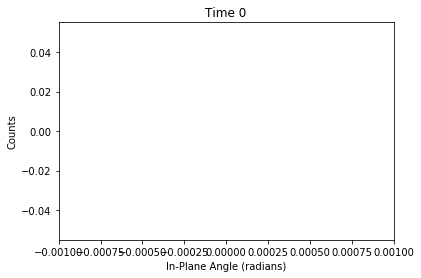

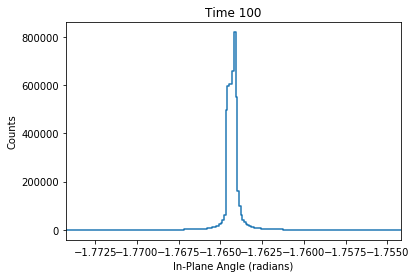

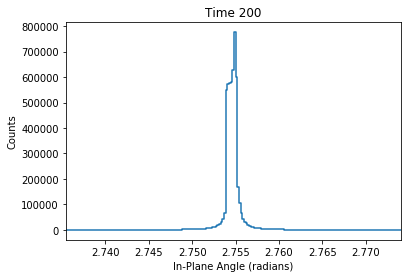

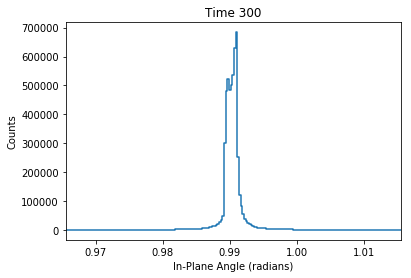

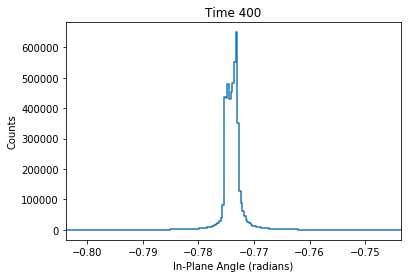

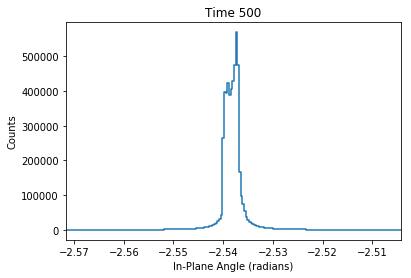

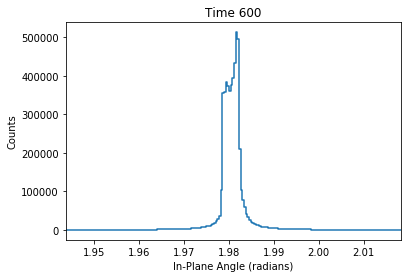

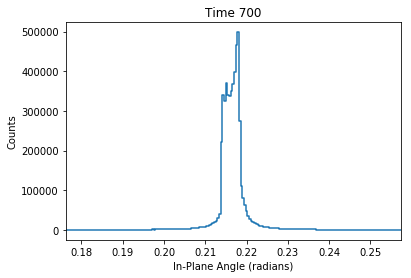

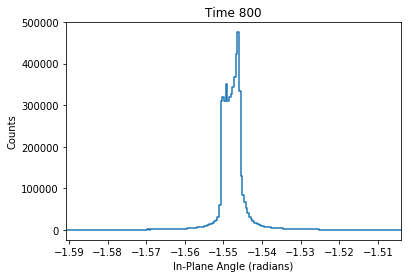

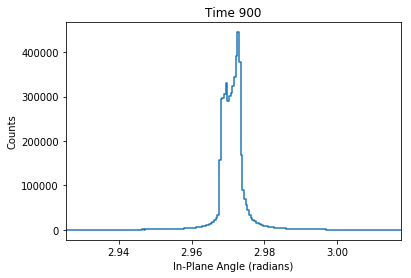

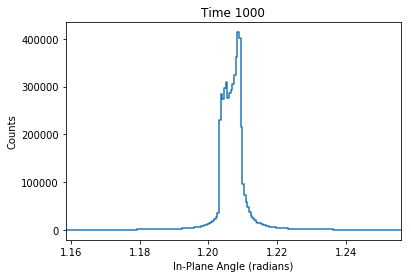

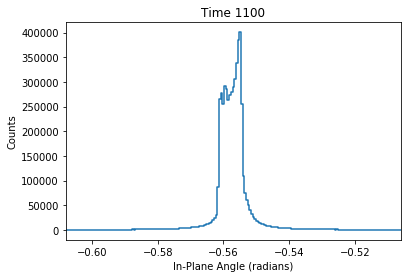

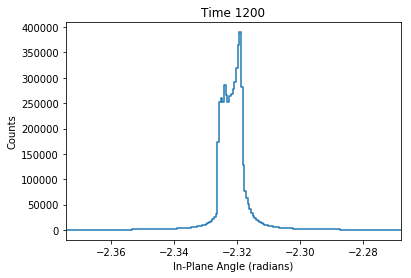

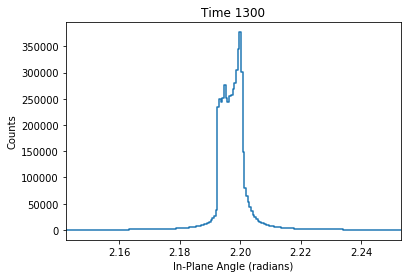

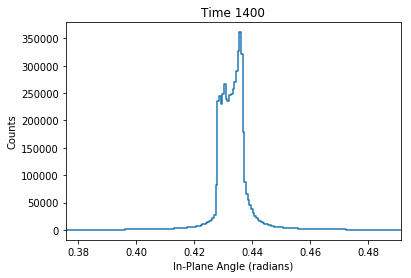

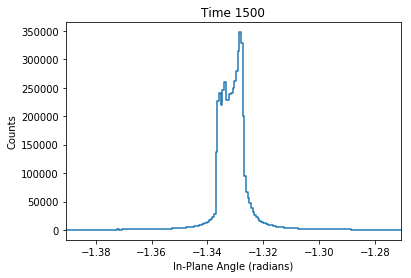

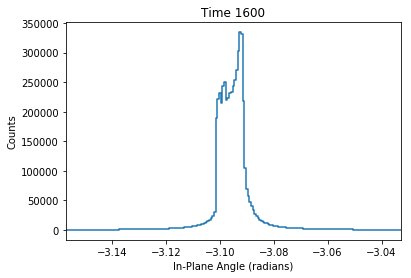

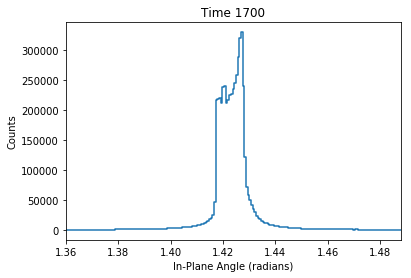

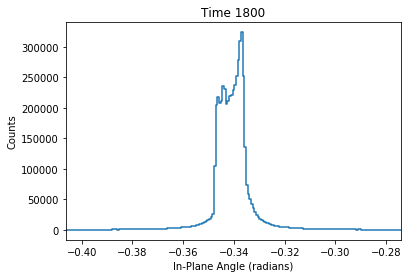

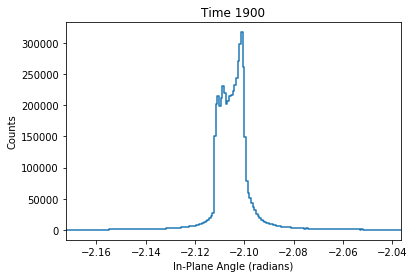

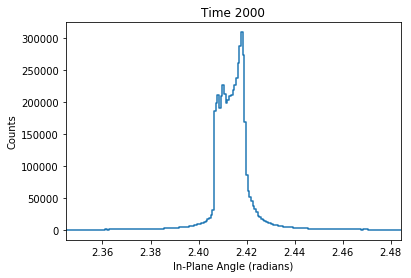

In [16]:
numBins = 400
width = 2
times = np.arange(0, 2100, 100)
for i in range(len(times)):
    out = outputs[i]
    out = out.flatten()
    mean = np.mean(out)
    std = np.std(out)
    valid = out[abs(out-mean)<(std*width)]
    hist, bins = np.histogram(valid, bins = numBins)
    plt.step((bins[:-1]+bins[1:])/2.0, hist)
    #plt.yscale('log')
    plt.xlim(mean-std, mean+std)
    plt.title('Time '+str(times[i]))
    plt.xlabel('In-Plane Angle (radians)')
    plt.ylabel('Counts')
    plt.show()

5242880
[0.e+00 0.e+00 3.e-06] 0.4 [      0.       0. 7500000.] [0.07 0.1  0.4 ]
-623.4 0.010078898471574569


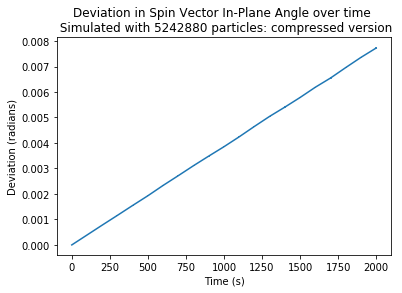

In [17]:
params, data = readInOutputFile(original[0])
numParticles = data.shape[0]*len(original)
print(numParticles)
print(params['B0'], params['T'], params['E'], params['L'])
w = params['gamma']*np.sqrt(np.sum(np.square(params['B0']))) #calculate the frequency
period = abs(2.0*np.pi/w) #calculate the period of the oscillation
print(w, period)
times = np.arange(0, 2100, 100)
locationInPeriod = (times/period)%1
trueAngle = locationInPeriod*2.0*np.pi
shiftedMeans = means[:]
shiftedMeans[shiftedMeans<0] += np.pi*2.0
plt.errorbar(times, shiftedMeans-trueAngle, yerr=stds/np.sqrt(numParticles))
#plt.plot(times, trueAngle)
plt.xlabel('Time (s)')
plt.ylabel('Deviation (radians)')
plt.title('Deviation in Spin Vector In-Plane Angle over time \n Simulated with '+str(numParticles) +' particles: compressed version')
plt.show()

In [18]:
def bootstrapFit(times, data, numIter, period):
    slopes = []
    offsets = []
    for i in range(numIter):
        print(i)
        means = []
        for j in range(data.shape[0]):
            flat = data[j].flatten()
            samples = np.random.choice(flat, size=flat.shape)
            means.append(np.mean(samples))
        means = np.array(means)
        shiftedMeans = means[:]
        shiftedMeans[shiftedMeans<0] += np.pi*2.0
        locationInPeriod = (times/period)%1
        trueAngle = locationInPeriod*2.0*np.pi
        difference = shiftedMeans - trueAngle
        fitRes = np.polyfit(times, difference, deg=1)
        slopes.append(fitRes[0])
        offsets.append(fitRes[1])
    slopes = np.array(slopes)
    offsets = np.array(offsets)
    return slopes, offsets

In [21]:
slopes, offsets = bootstrapFit(times, outputs, 20, period)

0
1
2
3
4
5
6
7
8
9
12
13
14
15
16
17
18
19


In [20]:
error = np.sqrt(1/(100-1)*np.sum((slopes-np.mean(slopes))**2.0))
print(np.mean(slopes), error)

3.860033043212134e-06 2.200131732057693e-09
